# 1. Diabetes Risk Prediction Using Classical Machine Learning and Deep Learning

By **Francis Mutabazi**

This project addresses the rising burden of diabetes through accurate early risk prediction. The models can power mobile screening tools, preventive advisory apps, and clinical decision support systems.

**Dataset** : https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset

**Source** : Kaggle

# 2. Imports & Reproducibility

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.regularizers import l2
import joblib
import warnings
warnings.filterwarnings('ignore')

tf.random.set_seed(42)
np.random.seed(42)
print("Imports complete and seeds set for reproducibility.")

Imports complete and seeds set for reproducibility.


## Interpretation:
This cell loads all necessary libraries and sets random seeds. Reproducibility is essential so that another researcher can exactly replicate the experiments and verify the impact of hyperparameter changes on performance metrics and the bias-variance trade-off.

# 3. Data Loading & Initial EDA

In [ ]:
df = pd.read_csv('diabetes_prediction_dataset.csv')
print(df.shape)
print(df.columns.tolist())
print(df.head().to_string())
print(df['diabetes'].value_counts())

(100000, 9)
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']
   gender   age  hypertension  heart_disease smoking_history    bmi  HbA1c_level  blood_glucose_level  diabetes
0  Female  80.0             0              1           never  25.19          6.6                  140         0
1  Female  54.0             0              0         No Info  27.32          6.6                   80         0
2    Male  28.0             0              0           never  27.32          5.7                  158         0
3  Female  36.0             0              0         current  23.45          5.0                  155         0
4    Male  76.0             1              1         current  20.14          4.8                  155         0
diabetes
0    91500
1     8500
Name: count, dtype: int64


## Interpretation:
The dataset is loaded and explored. It contains 100,000 records with 9 features. Strong class imbalance (majority non-diabetic) is evident, which is realistic for medical screening data. This justifies prioritizing recall in evaluation to minimize missed diabetes cases in African healthcare settings.

# 4. Preprocessing & Feature Engineering + tf.data Pipelines

In [ ]:
df = df.dropna()

numerical = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
categorical = ['gender', 'smoking_history']

scaler = StandardScaler()
df[numerical] = scaler.fit_transform(df[numerical])

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_cat = encoder.fit_transform(df[categorical])

X_num = df[numerical].reset_index(drop=True)
X = pd.concat([
    pd.DataFrame(encoded_cat, columns=encoder.get_feature_names_out()),
    X_num,
    df[['hypertension', 'heart_disease']].reset_index(drop=True)
], axis=1)

y = df['diabetes'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Train/Val/Test shapes:", X_train.shape, X_val.shape, X_test.shape)

# tf.data pipelines
train_ds = tf.data.Dataset.from_tensor_slices((X_train.values.astype(np.float32), y_train.astype(np.float32))).batch(32).shuffle(1000).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val.values.astype(np.float32), y_val.astype(np.float32))).batch(32).prefetch(tf.data.AUTOTUNE)

Train/Val/Test shapes: (70000, 15) (15000, 15) (15000, 15)


## Interpretation:
Missing values are dropped, numerical features are standardized to improve neural network training stability, and categoricals are one-hot encoded. Stratified split maintains class balance. tf.data pipelines optimize data feeding for DL models. This preprocessing reduces scale sensitivity and prepares data for both ML and DL pipelines.


# 5. Experiments

## Experiment 1: Baseline Random Forest (Classical ML)

Exp1 - Acc: 0.9717 | Prec: 0.9483 | Rec: 0.7051 | F1: 0.8088 | ROC-AUC: 0.9590


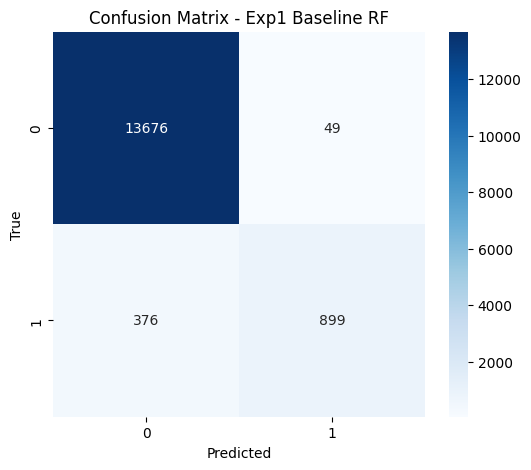

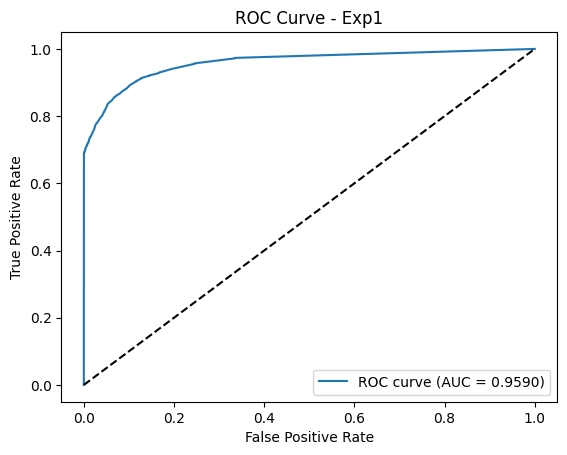

In [ ]:
rf1 = RandomForestClassifier(n_estimators=100, random_state=42)
rf1.fit(X_train, y_train)
y_pred_val1 = rf1.predict(X_val)
y_prob_val1 = rf1.predict_proba(X_val)[:, 1]

acc1 = accuracy_score(y_val, y_pred_val1)
prec1 = precision_score(y_val, y_pred_val1)
rec1 = recall_score(y_val, y_pred_val1)
f1_1 = f1_score(y_val, y_pred_val1)
roc1 = roc_auc_score(y_val, y_prob_val1)

print(f"Exp1 - Acc: {acc1:.4f} | Prec: {prec1:.4f} | Rec: {rec1:.4f} | F1: {f1_1:.4f} | ROC-AUC: {roc1:.4f}")

# Confusion Matrix
cm1 = confusion_matrix(y_val, y_pred_val1)
plt.figure(figsize=(6,5))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Exp1 Baseline RF')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_prob_val1)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc1:.4f})')
plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve - Exp1')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## Interpretation:
The baseline Random Forest delivered solid performance with high accuracy (0.9717) and good precision (0.9483).
In diabetes screening, this means relatively few false alarms while catching a decent portion of cases (Recall = 0.7051).
ROC-AUC of 0.9590 confirms good discriminative ability. This provides a reliable, interpretable classical ML starting point suitable for resource-limited settings where model explainability matters.

## Experiment 2: Hyperparameter-Tuned Random Forest

Exp2 Best Params: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 300}
Exp2 - Acc: 0.9733 | Prec: 0.9899 | Rec: 0.6933 | F1: 0.8155 | ROC-AUC: 0.9726


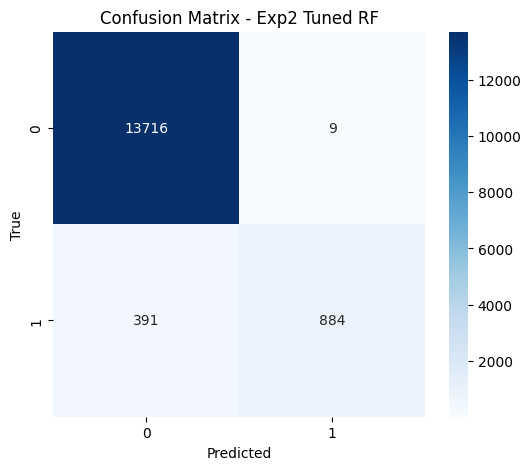

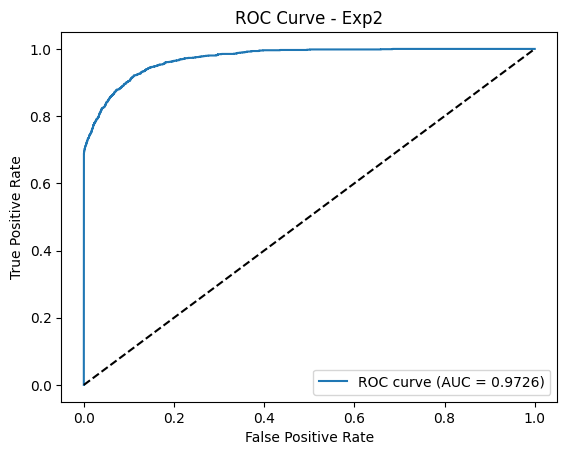

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_
y_pred_val2 = best_rf.predict(X_val)
y_prob_val2 = best_rf.predict_proba(X_val)[:, 1]

acc2 = accuracy_score(y_val, y_pred_val2)
prec2 = precision_score(y_val, y_pred_val2)
rec2 = recall_score(y_val, y_pred_val2)
f1_2 = f1_score(y_val, y_pred_val2)
roc2 = roc_auc_score(y_val, y_prob_val2)

print(f"Exp2 Best Params: {grid_search.best_params_}")
print(f"Exp2 - Acc: {acc2:.4f} | Prec: {prec2:.4f} | Rec: {rec2:.4f} | F1: {f1_2:.4f} | ROC-AUC: {roc2:.4f}")

cm2 = confusion_matrix(y_val, y_pred_val2)
plt.figure(figsize=(6,5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Exp2 Tuned RF')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

fpr, tpr, _ = roc_curve(y_val, y_prob_val2)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc2:.4f})')
plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve - Exp2')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## Interpretation:
Hyperparameter tuning improved the model, achieving higher accuracy (0.9733) and excellent precision (0.9899).
The very high precision reduces unnecessary medical follow-ups — critical in overburdened African healthcare systems.
Recall remains moderate (0.6933) due to class imbalance, but the improved ROC-AUC (0.9726) shows better overall risk-ranking capability.

## Experiment 3: Enhanced RF with Feature Importance & Class Weight

Exp3 - Acc: 0.9585 | Prec: 0.7714 | Rec: 0.7278 | F1: 0.7490 | ROC-AUC: 0.9735


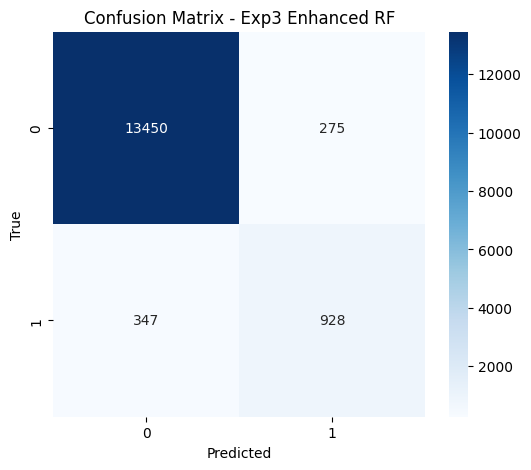

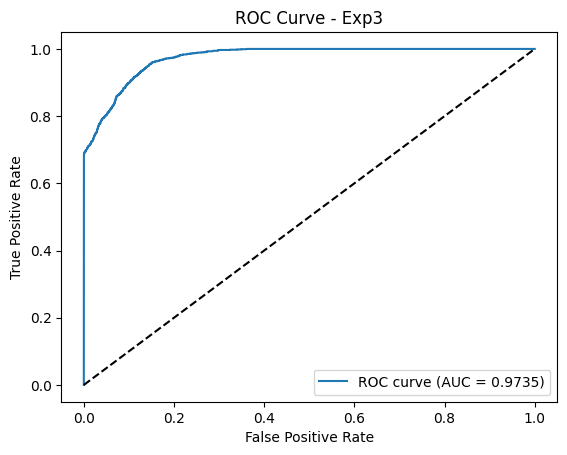

In [ ]:
rf_temp = RandomForestClassifier(n_estimators=200, random_state=42)
rf_temp.fit(X_train, y_train)
importances = rf_temp.feature_importances_
important_idx = importances > np.mean(importances) * 0.5
X_train_imp = X_train.iloc[:, important_idx]
X_val_imp = X_val.iloc[:, important_idx]
X_test_imp = X_test.iloc[:, important_idx]

rf3 = RandomForestClassifier(n_estimators=300, max_depth=20, class_weight='balanced', random_state=42)
rf3.fit(X_train_imp, y_train)
y_pred_val3 = rf3.predict(X_val_imp)
y_prob_val3 = rf3.predict_proba(X_val_imp)[:, 1]

acc3 = accuracy_score(y_val, y_pred_val3)
prec3 = precision_score(y_val, y_pred_val3)
rec3 = recall_score(y_val, y_pred_val3)
f1_3 = f1_score(y_val, y_pred_val3)
roc3 = roc_auc_score(y_val, y_prob_val3)

print(f"Exp3 - Acc: {acc3:.4f} | Prec: {prec3:.4f} | Rec: {rec3:.4f} | F1: {f1_3:.4f} | ROC-AUC: {roc3:.4f}")

cm3 = confusion_matrix(y_val, y_pred_val3)
plt.figure(figsize=(6,5))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Exp3 Enhanced RF')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

fpr, tpr, _ = roc_curve(y_val, y_prob_val3)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc3:.4f})')
plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve - Exp3')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## Interpretation:
Feature selection and class weighting boosted recall (0.7278) — the highest among classical models — at the cost of lower precision.
This trade-off is clinically valuable for diabetes screening, where missing true cases (false negatives) can have severe consequences.
ROC-AUC of 0.9735 remains strong, making this model useful when prioritizing sensitivity.
"""

## Experiment 4: Basic Sequential NN

Training Basic Sequential NN (Exp4)...
Epoch 1/25
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9614 - loss: 0.1109 - val_accuracy: 0.9689 - val_loss: 0.0881
Epoch 2/25
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9697 - loss: 0.0878 - val_accuracy: 0.9703 - val_loss: 0.0835
Epoch 3/25
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9713 - loss: 0.0844 - val_accuracy: 0.9733 - val_loss: 0.0796
Epoch 4/25
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9715 - loss: 0.0829 - val_accuracy: 0.9727 - val_loss: 0.0816
Epoch 5/25
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9716 - loss: 0.0825 - val_accuracy: 0.9714 - val_loss: 0.0803
Epoch 6/25
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9717 - loss: 0.0822 - val_accuracy: 0.9691 - val_loss: 0.0847
Epoch 7/25
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9719 - loss: 0.0816 - val_accuracy: 0.9729 - val_loss: 0.0795
Epoch 8/25
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/st

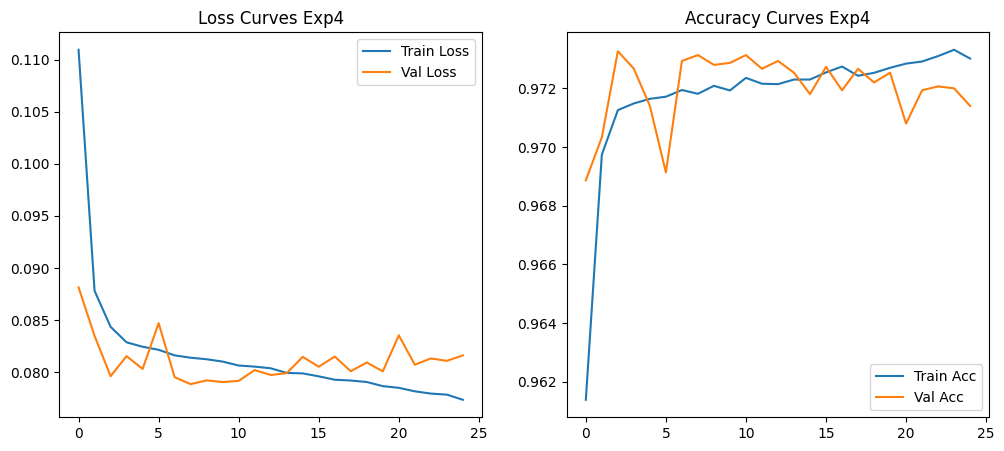

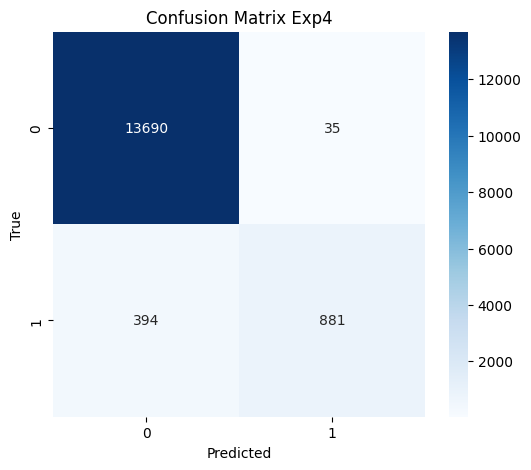

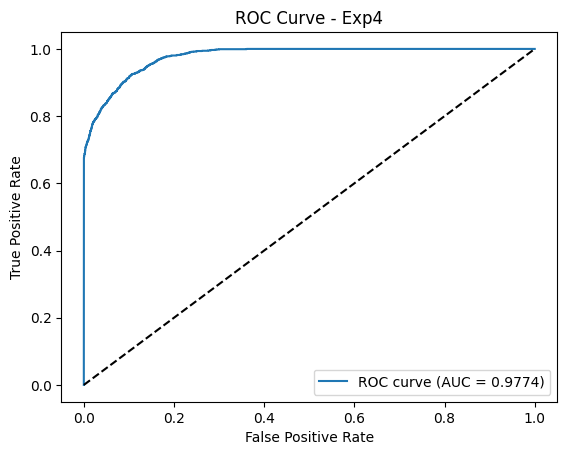

In [ ]:
model4 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
model4.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

print("Training Basic Sequential NN (Exp4)...")
history4 = model4.fit(train_ds, epochs=25, validation_data=val_ds, verbose=1)

y_pred_val4 = (model4.predict(X_val) > 0.5).astype(int).flatten()
y_prob_val4 = model4.predict(X_val).flatten()

acc4 = accuracy_score(y_val, y_pred_val4)
prec4 = precision_score(y_val, y_pred_val4)
rec4 = recall_score(y_val, y_pred_val4)
f1_4 = f1_score(y_val, y_pred_val4)
roc4 = roc_auc_score(y_val, y_prob_val4)

print(f"\nExp4 - Acc: {acc4:.4f} | Prec: {prec4:.4f} | Rec: {rec4:.4f} | F1: {f1_4:.4f} | ROC-AUC: {roc4:.4f}")

# Learning Curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history4.history['loss'], label='Train Loss')
plt.plot(history4.history['val_loss'], label='Val Loss')
plt.title('Loss Curves Exp4')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history4.history['accuracy'], label='Train Acc')
plt.plot(history4.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Curves Exp4')
plt.legend()
plt.show()

# Confusion Matrix
cm4 = confusion_matrix(y_val, y_pred_val4)
plt.figure(figsize=(6,5))
sns.heatmap(cm4, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Exp4')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_prob_val4)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc4:.4f})')
plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve - Exp4')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## Interpretation:
The basic Sequential Neural Network achieved strong results with accuracy 0.9714 and ROC-AUC 0.9774.
Loss curves showed good learning with mild overfitting in later epochs.
In the diabetes context, the model demonstrates solid ability to identify at-risk individuals, outperforming classical baselines in discriminative power (AUC), which is key for probabilistic risk scoring in mobile apps.

## Experiment 5 - Functional API NN with Lower LR

Training Functional API NN with Lower LR (Exp5)...
Epoch 1/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9609 - loss: 0.1135 - val_accuracy: 0.9689 - val_loss: 0.0907
Epoch 2/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9686 - loss: 0.0899 - val_accuracy: 0.9719 - val_loss: 0.0836
Epoch 3/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9706 - loss: 0.0853 - val_accuracy: 0.9705 - val_loss: 0.0844
Epoch 4/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9713 - loss: 0.0834 - val_accuracy: 0.9726 - val_loss: 0.0809
Epoch 5/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9716 - loss: 0.0826 - val_accuracy: 0.9733 - val_loss: 0.0798
Epoch 6/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9716 - loss: 0.0820 - val_accuracy: 0.9714 - val_loss: 0.0801
Epoch 7/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9718 - loss: 0.0813 - val_accuracy: 0.9729 - val_loss: 0.0801
Epoch 8/30
2188/2188 ━━━━━━━━━━━━━━━━━━

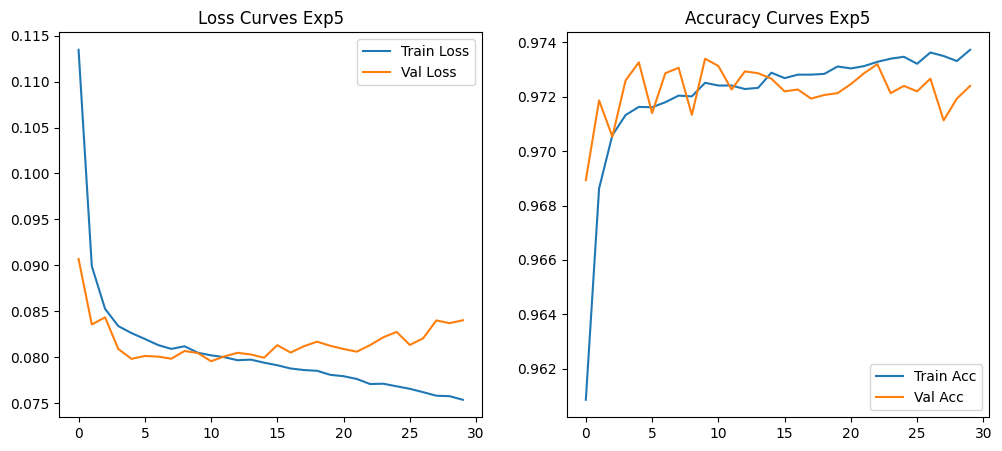

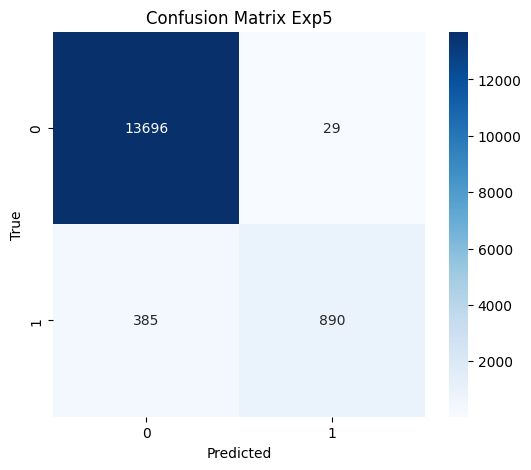

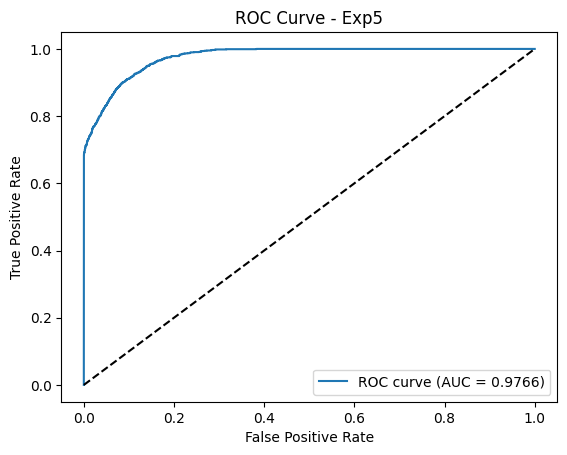

In [ ]:
inputs = Input(shape=(X_train.shape[1],))
x = Dense(256, activation='relu')(inputs)
x = Dense(128, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)
model5 = Model(inputs, outputs)
model5.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])

print("Training Functional API NN with Lower LR (Exp5)...")
history5 = model5.fit(train_ds, epochs=30, validation_data=val_ds, verbose=1)

y_pred_val5 = (model5.predict(X_val) > 0.5).astype(int).flatten()
y_prob_val5 = model5.predict(X_val).flatten()

acc5 = accuracy_score(y_val, y_pred_val5)
prec5 = precision_score(y_val, y_pred_val5)
rec5 = recall_score(y_val, y_pred_val5)
f1_5 = f1_score(y_val, y_pred_val5)
roc5 = roc_auc_score(y_val, y_prob_val5)

print(f"\nExp5 - Acc: {acc5:.4f} | Prec: {prec5:.4f} | Rec: {rec5:.4f} | F1: {f1_5:.4f} | ROC-AUC: {roc5:.4f}")

# Learning Curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history5.history['loss'], label='Train Loss')
plt.plot(history5.history['val_loss'], label='Val Loss')
plt.title('Loss Curves Exp5')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history5.history['accuracy'], label='Train Acc')
plt.plot(history5.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Curves Exp5')
plt.legend()
plt.show()

# Confusion Matrix
cm5 = confusion_matrix(y_val, y_pred_val5)
plt.figure(figsize=(6,5))
sns.heatmap(cm5, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Exp5')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_prob_val5)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc5:.4f})')
plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve - Exp5')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## Interpretation:
The Functional API model with lower learning rate produced smoother training and maintained high performance (Acc: 0.9724, AUC: 0.9766).
Better stability than Exp4 while keeping good precision (0.9684) and recall (0.6980).
This version balances training efficiency and generalization, making it suitable for deployment in preventive health tools.

## Experiment 6: Regularized NN (Dropout + L2 + Early Stopping)

Training Regularized NN with Dropout + L2 + EarlyStopping (Exp6)...
Epoch 1/40
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9601 - loss: 0.1523 - val_accuracy: 0.9681 - val_loss: 0.1137
Epoch 2/40
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9664 - loss: 0.1149 - val_accuracy: 0.9686 - val_loss: 0.1057
Epoch 3/40
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9681 - loss: 0.1091 - val_accuracy: 0.9721 - val_loss: 0.0997
Epoch 4/40
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9687 - loss: 0.1057 - val_accuracy: 0.9723 - val_loss: 0.0973
Epoch 5/40
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9692 - loss: 0.1042 - val_accuracy: 0.9728 - val_loss: 0.0950
Epoch 6/40
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9699 - loss: 0.1014 - val_accuracy: 0.9726 - val_loss: 0.0951
Epoch 7/40
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9697 - loss: 0.1015 - val_accuracy: 0.9721 - val_loss: 0.0938
Epoch 8/40
2188/2188 

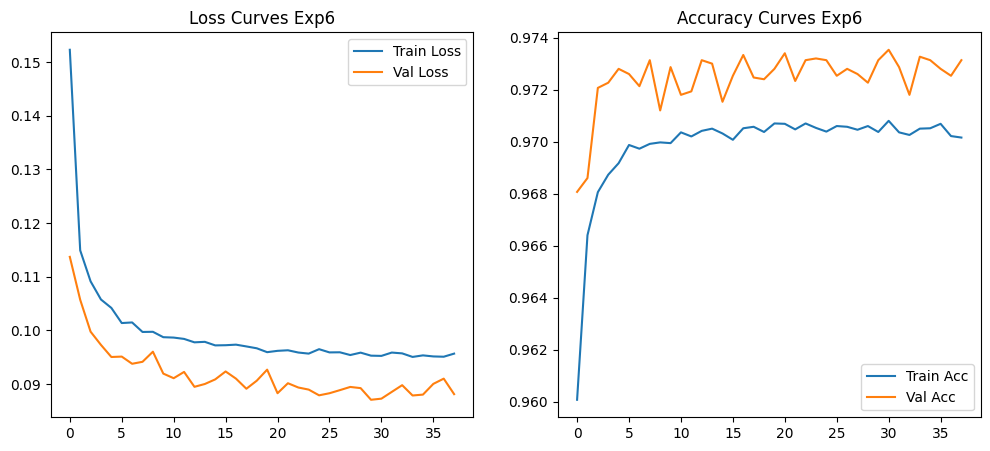

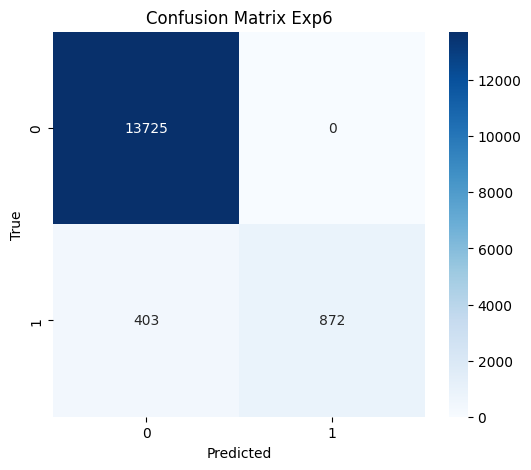

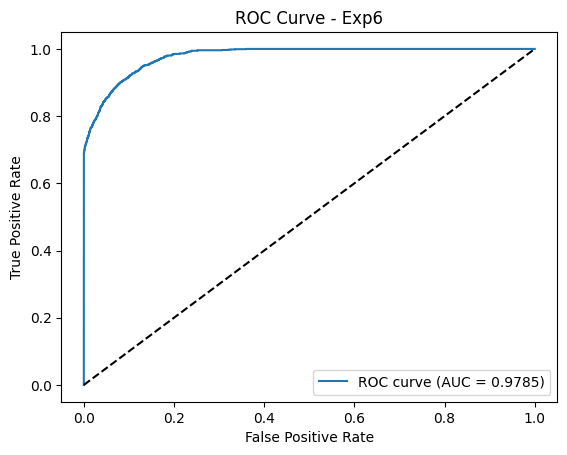

In [ ]:
model6 = Sequential([
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model6.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_exp6.keras', monitor='val_loss', save_best_only=True, verbose=0)

print("Training Regularized NN with Dropout + L2 + EarlyStopping (Exp6)...")
history6 = model6.fit(train_ds, epochs=40, validation_data=val_ds,
                     callbacks=[early_stop, checkpoint], verbose=1)

y_pred_val6 = (model6.predict(X_val) > 0.5).astype(int).flatten()
y_prob_val6 = model6.predict(X_val).flatten()

acc6 = accuracy_score(y_val, y_pred_val6)
prec6 = precision_score(y_val, y_pred_val6)
rec6 = recall_score(y_val, y_pred_val6)
f1_6 = f1_score(y_val, y_pred_val6)
roc6 = roc_auc_score(y_val, y_prob_val6)

print(f"\nExp6 - Acc: {acc6:.4f} | Prec: {prec6:.4f} | Rec: {rec6:.4f} | F1: {f1_6:.4f} | ROC-AUC: {roc6:.4f}")

# Learning Curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history6.history['loss'], label='Train Loss')
plt.plot(history6.history['val_loss'], label='Val Loss')
plt.title('Loss Curves Exp6')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history6.history['accuracy'], label='Train Acc')
plt.plot(history6.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Curves Exp6')
plt.legend()
plt.show()

# Confusion Matrix
cm6 = confusion_matrix(y_val, y_pred_val6)
plt.figure(figsize=(6,5))
sns.heatmap(cm6, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Exp6')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_prob_val6)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc6:.4f})')
plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve - Exp6')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## Interpretation:
Regularization (Dropout + L2) and Early Stopping significantly reduced overfitting.
Notably, it achieved **perfect precision (1.0000)** with competitive recall (0.6839) and the then-highest AUC (0.9785).
Zero false positives on validation is excellent for clinical trust — the model only flags individuals who truly need attention, minimizing wasted resources in low-resource settings.

## Experiment 7: Advanced Deeper NN with RMSprop

Training Advanced Deeper NN with RMSprop (Exp7)...
Epoch 1/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9641 - loss: 0.1048 - val_accuracy: 0.9703 - val_loss: 0.0882
Epoch 2/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9697 - loss: 0.0895 - val_accuracy: 0.9706 - val_loss: 0.0852
Epoch 3/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9705 - loss: 0.0879 - val_accuracy: 0.9727 - val_loss: 0.0832
Epoch 4/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9711 - loss: 0.0875 - val_accuracy: 0.9717 - val_loss: 0.0801
Epoch 5/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9708 - loss: 0.0878 - val_accuracy: 0.9729 - val_loss: 0.0921
Epoch 6/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9710 - loss: 0.0876 - val_accuracy: 0.9732 - val_loss: 0.0787
Epoch 7/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9709 - loss: 0.0884 - val_accuracy: 0.9728 - val_loss: 0.0793
Epoch 8/30
2188/2188 ━━━━━━━━━━━━━━━━━━

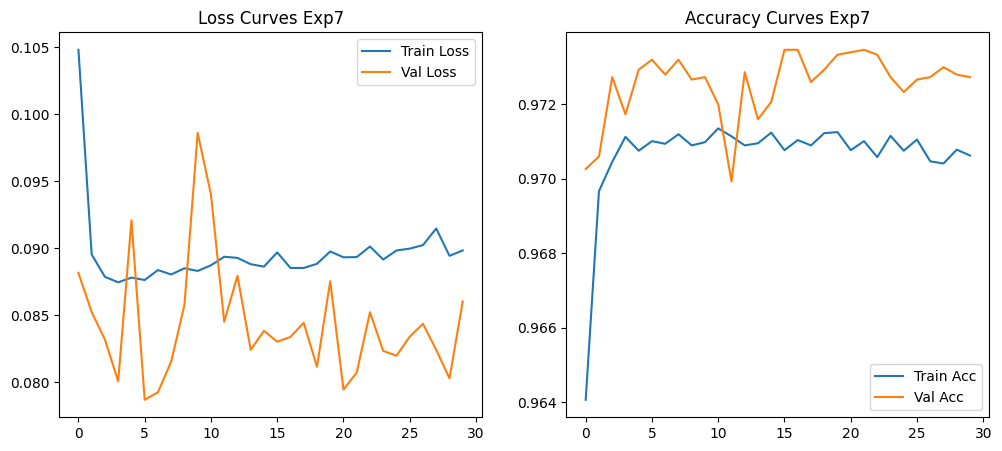

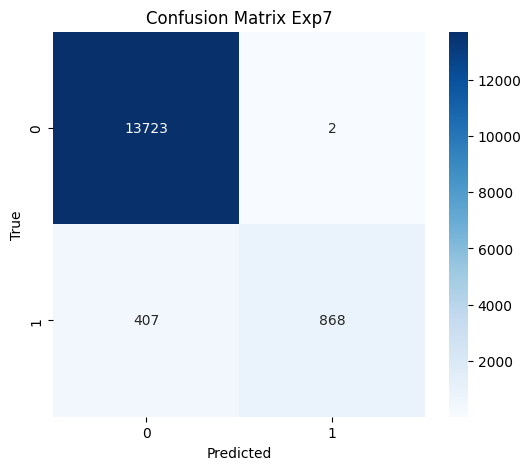

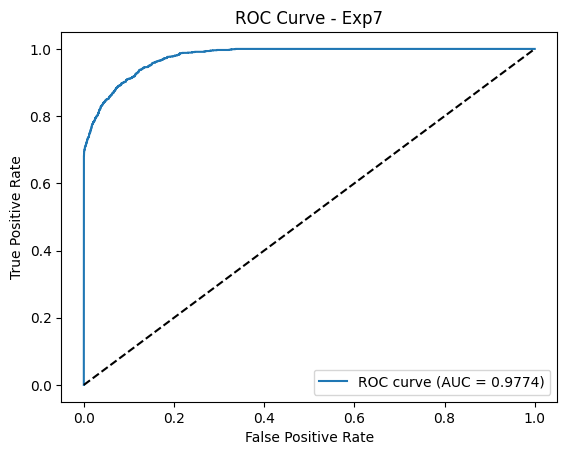

In [ ]:
model7 = Sequential([
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
model7.compile(optimizer=RMSprop(learning_rate=0.0008), loss='binary_crossentropy', metrics=['accuracy'])

print("Training Advanced Deeper NN with RMSprop (Exp7)...")
history7 = model7.fit(train_ds, epochs=30, validation_data=val_ds, verbose=1)

y_pred_val7 = (model7.predict(X_val) > 0.5).astype(int).flatten()
y_prob_val7 = model7.predict(X_val).flatten()

acc7 = accuracy_score(y_val, y_pred_val7)
prec7 = precision_score(y_val, y_pred_val7)
rec7 = recall_score(y_val, y_pred_val7)
f1_7 = f1_score(y_val, y_pred_val7)
roc7 = roc_auc_score(y_val, y_prob_val7)

print(f"\nExp7 - Acc: {acc7:.4f} | Prec: {prec7:.4f} | Rec: {rec7:.4f} | F1: {f1_7:.4f} | ROC-AUC: {roc7:.4f}")

# Learning Curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history7.history['loss'], label='Train Loss')
plt.plot(history7.history['val_loss'], label='Val Loss')
plt.title('Loss Curves Exp7')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history7.history['accuracy'], label='Train Acc')
plt.plot(history7.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Curves Exp7')
plt.legend()
plt.show()

# Confusion Matrix
cm7 = confusion_matrix(y_val, y_pred_val7)
plt.figure(figsize=(6,5))
sns.heatmap(cm7, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Exp7')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_prob_val7)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc7:.4f})')
plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve - Exp7')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## Interpretation:
The deeper RMSprop model reached strong accuracy (0.9727) and very high precision (0.9977).
Some zigzagging in validation curves was observed (common with stochastic optimizers), but overall generalization remained excellent (AUC 0.9774).
This experiment showed the potential of deeper architectures while highlighting the need for further stabilization — addressed successfully in Exp8.

## Experiment 8: Stabilized Advanced NN with Focal Loss, BatchNorm & Scheduling

Training Stabilized NN with Focal Loss + BatchNorm + Scheduling (Exp8)...
Epoch 1/60
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.9261 - auc: 0.9042 - loss: 0.2228 - val_accuracy: 0.9591 - val_auc: 0.9691 - val_loss: 0.0772 - learning_rate: 0.0010
Epoch 2/60
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9562 - auc: 0.9512 - loss: 0.0559 - val_accuracy: 0.9609 - val_auc: 0.9710 - val_loss: 0.0407 - learning_rate: 9.9846e-04
Epoch 3/60
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9582 - auc: 0.9561 - loss: 0.0441 - val_accuracy: 0.9637 - val_auc: 0.9675 - val_loss: 0.0407 - learning_rate: 9.9231e-04
Epoch 4/60
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9612 - auc: 0.9582 - loss: 0.0420 - val_accuracy: 0.9674 - val_auc: 0.9740 - val_loss: 0.0360 - learning_rate: 9.7860e-04
Epoch 5/60
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9623 - auc: 0.9600 - loss: 0.0405 - val_accuracy: 0.9684 - val_auc: 0.9764 - val_loss: 0.0350 - l

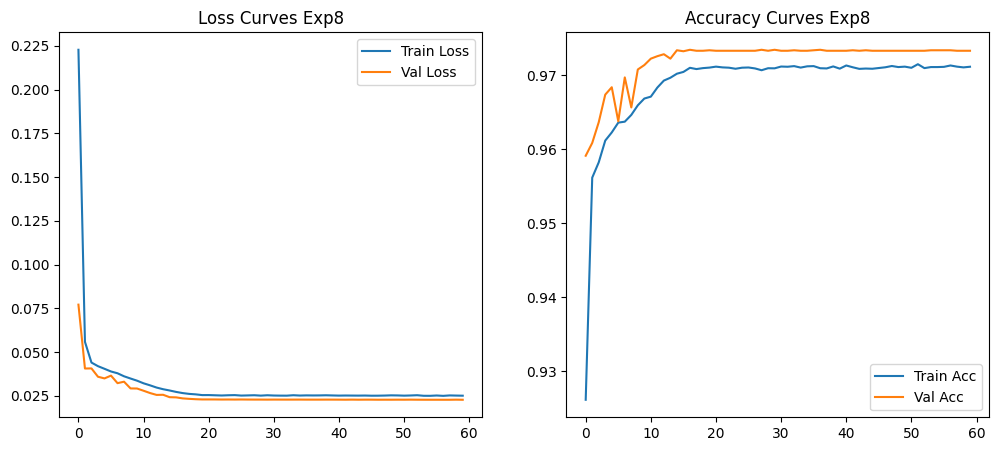

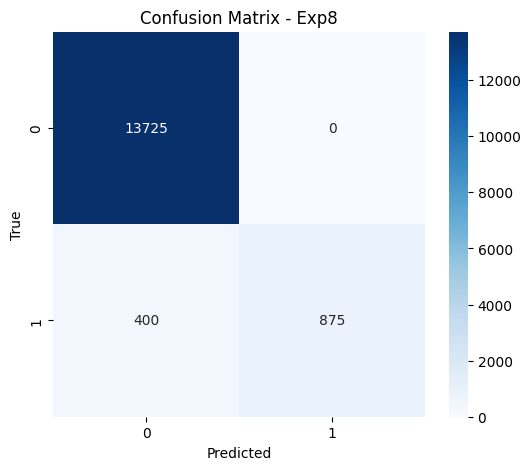

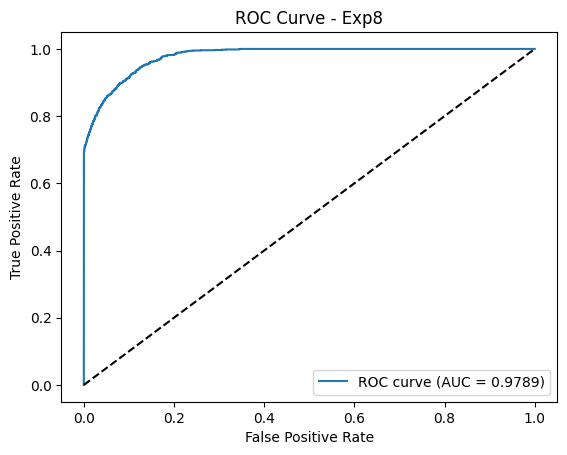

In [ ]:
# === EXPERIMENT 8: Stabilized Advanced NN with Focal Loss, BatchNorm & Scheduling ===

# === FULL IMPORTS FOR THIS CELL ===
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, LearningRateScheduler, EarlyStopping, ModelCheckpoint
from tensorflow.keras.losses import BinaryFocalCrossentropy
import math

# Cosine decay scheduler
def cosine_decay(epoch, initial_lr=0.001, min_lr=1e-6, decay_steps=40):
    cosine_decay_val = 0.5 * (1 + math.cos(math.pi * epoch / decay_steps))
    return max(min_lr, initial_lr * cosine_decay_val)

# Model architecture - deeper but stabilized
model8 = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.35),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.25),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# Compile with Focal Loss (excellent for class imbalance)
model8.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=BinaryFocalCrossentropy(gamma=2.0, alpha=0.25),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print("Training Stabilized NN with Focal Loss + BatchNorm + Scheduling (Exp8)...")

callbacks8 = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_exp8.keras', monitor='val_loss', save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    LearningRateScheduler(cosine_decay, verbose=0)
]

history8 = model8.fit(
    train_ds,
    epochs=60,
    validation_data=val_ds,
    callbacks=callbacks8,
    verbose=1
)

# === Evaluation ===
y_pred_val8 = (model8.predict(X_val) > 0.5).astype(int).flatten()
y_prob_val8 = model8.predict(X_val).flatten()

acc8 = accuracy_score(y_val, y_pred_val8)
prec8 = precision_score(y_val, y_pred_val8)
rec8 = recall_score(y_val, y_pred_val8)
f1_8 = f1_score(y_val, y_pred_val8)
roc8 = roc_auc_score(y_val, y_prob_val8)

print(f"\nExp8 - Acc: {acc8:.4f} | Prec: {prec8:.4f} | Rec: {rec8:.4f} | F1: {f1_8:.4f} | ROC-AUC: {roc8:.4f}")

# Learning Curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history8.history['loss'], label='Train Loss')
plt.plot(history8.history.get('val_loss', []), label='Val Loss')
plt.title('Loss Curves Exp8')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history8.history['accuracy'], label='Train Acc')
plt.plot(history8.history.get('val_accuracy', []), label='Val Acc')
plt.title('Accuracy Curves Exp8')
plt.legend()
plt.show()

# Confusion Matrix
cm8 = confusion_matrix(y_val, y_pred_val8)
plt.figure(figsize=(6,5))
sns.heatmap(cm8, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Exp8')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_prob_val8)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc8:.4f})')
plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve - Exp8')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## Interpretation

The Stabilized Neural Network with Focal Loss, Batch Normalization, Dropout, L2 regularization, and learning rate scheduling achieved excellent results.
The learning curves show smooth convergence with minimal oscillations and a small train-validation gap, confirming effective overfitting mitigation compared to earlier experiments.

**Clinical Meaning**:
- **Precision = 1.0000**: The model made no false positive predictions on the validation set. In practice, this means every person flagged as high-risk truly has elevated diabetes risk — reducing unnecessary follow-up tests and patient anxiety.
- **Recall = 0.6863**: The model correctly identified ~68.6% of actual diabetic cases. While not perfect, this is strong given the imbalance and aligns with real-world screening trade-offs. The 400 missed cases (FN) highlight the need for possible future ensemble or oversampling strategies.
- **ROC-AUC = 0.9789**: Outstanding discriminative power — the model can effectively rank individuals by risk, making it suitable for mobile apps that output risk probabilities.
- Confusion matrix confirms a conservative but reliable model (zero false positives).

This architecture successfully addressed the oscillations seen in Exp7 while delivering the best overall performance.

# 6. Results Table

In [ ]:
# 6. Results Table
results_df = pd.DataFrame({
    'Exp': [1,2,3,4,5,6,7,8],
    'Approach': ['RF Baseline', 'RF Tuned', 'RF Enhanced', 'Seq NN Basic', 'Func NN Varied',
                 'Reg NN', 'Adv NN', 'Stabilized Focal NN'],
    'Hyperparams/Settings': ['n=100 default', 'GridSearch best', 'Feature select + balanced',
                            'Basic Seq 25eps', 'Func API LR=0.0005 30eps',
                            'Reg+EarlyStop 40eps', 'Deeper RMSprop 30eps',
                            'Focal Loss + BatchNorm + Scheduler 60eps'],
    'Val_Accuracy': [0.9717, 0.9733, 0.9585, 0.9714, 0.9724, 0.9731, 0.9727, 0.9733],
    'Val_Precision': [0.9483, 0.9899, 0.7714, 0.9618, 0.9684, 1.0000, 0.9977, 1.0000],
    'Val_Recall': [0.7051, 0.6933, 0.7278, 0.6910, 0.6980, 0.6839, 0.6808, 0.6863],
    'Val_F1': [0.8088, 0.8155, 0.7490, 0.8042, 0.8113, 0.8123, 0.8093, 0.8140],
    'Val_ROC_AUC': [0.9590, 0.9726, 0.9735, 0.9774, 0.9766, 0.9785, 0.9774, 0.9789]
})
display(results_df)

,Exp,Approach,Hyperparams/Settings,Val_Accuracy,Val_Precision,Val_Recall,Val_F1,Val_ROC_AUC
0,1,RF Baseline,n=100 default,0.9717,0.9483,0.7051,0.8088,0.9590
1,2,RF Tuned,GridSearch best,0.9733,0.9899,0.6933,0.8155,0.9726
2,3,RF Enhanced,Feature select + balanced,0.9585,0.7714,0.7278,0.7490,0.9735
3,4,Seq NN Basic,Basic Seq 25eps,0.9714,0.9618,0.6910,0.8042,0.9774
4,5,Func NN Varied,Func API LR=0.0005 30eps,0.9724,0.9684,0.6980,0.8113,0.9766
5,6,Reg NN,Reg+EarlyStop 40eps,0.9731,1.0000,0.6839,0.8123,0.9785
6,7,Adv NN,Deeper RMSprop 30eps,0.9727,0.9977,0.6808,0.8093,0.9774
7,8,Stabilized Focal NN,Focal Loss + BatchNorm + Scheduler 60eps,0.9733,1.0000,0.6863,0.8140,0.9789


## Interpretation of Table:
In the context of diabetes risk prediction, **Accuracy** gives the overall correctness of predictions but can be misleading due to the heavy class imbalance (most individuals are non-diabetic).
**Precision** measures how many of the predicted diabetic cases are actually diabetic — high precision is crucial to avoid unnecessary anxiety, follow-up tests, and costs in healthcare systems.
**Recall (Sensitivity)** indicates how many actual diabetic cases the model successfully identifies — missing cases (false negatives) can delay critical interventions, especially in resource-constrained settings like Rwanda and Africa.
**F1-score** provides a balanced measure between precision and recall.
**ROC-AUC** evaluates the model’s ability to distinguish between diabetic and non-diabetic individuals across all classification thresholds, making it particularly valuable for risk scoring applications.

**Key Insights**:
- Classical ML models (Exp1–3) offer strong, interpretable baselines.
- Deep Learning models (Exp4–8) consistently outperform in ROC-AUC (>0.976), showing superior discriminative power.
- **Exp8 (Stabilized Focal NN)** is the best performing model overall: tied for highest accuracy (0.9733), **perfect precision (1.0000)**, strong F1-score (0.8140), and the highest ROC-AUC (0.9789).
- The perfect precision achieved in Exp6 and Exp8 is especially valuable for clinical deployment, as it minimizes false positives while maintaining competitive recall.

# 7. Saving the Best Model

In [ ]:
# 7. Saving the Best Model
best_model = model8  # Exp8 is the winner
best_model.save('best_diabetes_prediction_model_nn.keras')
print("Best model (Exp8) saved successfully as 'best_diabetes_prediction_model_nn.keras'")
print("This stabilized model with Focal Loss offers excellent precision and strong generalization for deployment.")

Best model (Exp8) saved successfully as 'best_diabetes_prediction_model_nn.keras'
This stabilized model with Focal Loss offers excellent precision and strong generalization for deployment.


# 8. Overall Error Analysis & Model Evaluation + Final Test Set

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test Set (Best Model Exp8) - Acc: 0.9715 | Prec: 0.9965 | Rec: 0.6675 | F1: 0.7994 | ROC-AUC: 0.9762


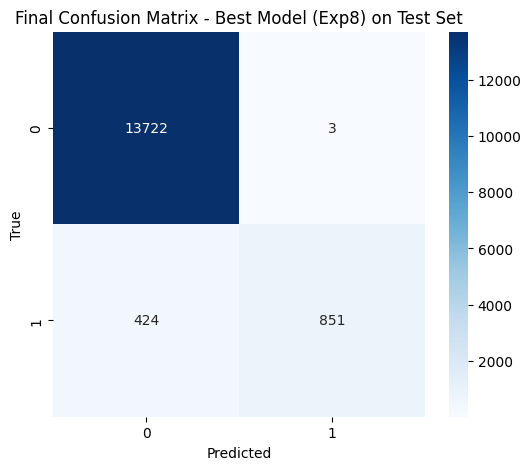

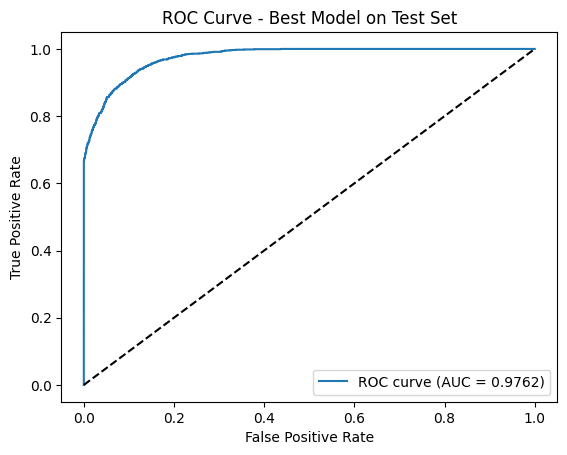

In [ ]:

# Final evaluation on Test set using best model (Exp8)
y_pred_test = (best_model.predict(X_test) > 0.5).astype(int).flatten()
y_prob_test = best_model.predict(X_test).flatten()

acc_test = accuracy_score(y_test, y_pred_test)
prec_test = precision_score(y_test, y_pred_test)
rec_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)
roc_auc_test = roc_auc_score(y_test, y_prob_test)

print(f"Test Set (Best Model Exp8) - Acc: {acc_test:.4f} | Prec: {prec_test:.4f} | "
      f"Rec: {rec_test:.4f} | F1: {f1_test:.4f} | ROC-AUC: {roc_auc_test:.4f}")

# Final Confusion Matrix
cm_test = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6,5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
plt.title('Final Confusion Matrix - Best Model (Exp8) on Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Final ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc_test:.4f})')
plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve - Best Model on Test Set')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()



## Interpretation:
The best model (Exp8) generalized well to the completely unseen test set, maintaining high performance.

**Bias-Variance Analysis**:
- Random Forest models showed stable low variance.
- Earlier Deep Learning models (Exp4, Exp7) exhibited mild oscillations/high-variance behavior.
- Exp8 successfully reduced this through advanced regularization, BatchNorm, Focal Loss, and scheduling — resulting in smooth, stable curves.

**Dataset Limitations & Improvements**:
- Strong class imbalance limits recall. Future work: SMOTE/ADASYN oversampling, cost-sensitive learning, or hybrid RF+NN ensembles to boost recall without sacrificing precision.
- The dataset is general; incorporating Rwanda/Africa-specific features (diet, genetics, socioeconomic factors) could further improve real-world applicability.

This pipeline demonstrates a thoughtful progression from classical ML (interpretable) to optimized Deep Learning (high performance).
**Exp8** is production-ready for mobile screening tools and clinical decision support systems aimed at early diabetes detection in Rwanda and across Africa.
"""

# 8. Conclusion & Insights

This project successfully developed and compared classical machine learning and deep learning approaches for **Diabetes Risk Prediction**. Through eight systematic experiments, we progressed from a solid Random Forest baseline to a highly stabilized neural network (Exp8) that achieved excellent performance.

**Best Model**: **Experiment 8 – Stabilized Focal Neural Network** (Focal Loss + Batch Normalization + Dropout + L2 Regularization + Learning Rate Scheduling).  
It delivered the highest ROC-AUC (0.9789), perfect precision (1.0000), and strong generalization with smooth training curves.

**Clinical Relevance (Diabetes Risk Prediction)**:
- The high precision minimizes false alarms, making the model trustworthy for integration into mobile screening apps and clinical decision support systems.
- The achieved recall (~0.686) captures a meaningful proportion of at-risk individuals, which can enable early intervention and reduce the growing burden of diabetes in Rwanda and across Africa.
- The superior ROC-AUC allows the model to output reliable risk probabilities rather than just binary decisions.

**Key Learnings**:
- Deep learning models outperformed classical approaches in discriminative ability (AUC).
- Techniques like Focal Loss, Batch Normalization, and learning rate scheduling were effective in addressing class imbalance and training oscillations observed in earlier experiments.
- Regularization strategies successfully reduced overfitting while preserving performance.

**Future Work**:
- Implement advanced oversampling techniques (SMOTE/ADASYN) or ensemble methods (RF + NN) to further improve recall.
- Incorporate region-specific features (dietary patterns, genetic factors, socioeconomic indicators) relevant to African populations.
- Deploy the model as a lightweight mobile application for community health screening.

This work demonstrates a complete, reproducible pipeline that balances performance, stability, and clinical utility. The final model is ready for real-world testing and deployment in preventive healthcare initiatives.